In [1]:
import pandas as pd
import numpy as np

hourly = pd.read_csv("df_hourly_2019_2025.csv")
honey = pd.read_csv("honey.csv", sep=";")
beehives = pd.read_csv("ule.csv", sep=";")

hourly["valid_time"] = pd.to_datetime(hourly["valid_time"])
hourly["year"] = hourly["valid_time"].dt.year
hourly["date"] = hourly["valid_time"].dt.date

hourly.head()

,valid_time,temp,wspd,prcp,pres,week,year,date
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18,2019,2019-05-01
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18,2019,2019-05-01
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18,2019,2019-05-01
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18,2019,2019-05-01
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18,2019,2019-05-01


In [2]:
honey = honey.sort_values(["year", "week", "harvest"]).reset_index(drop=True)

honey = honey.merge(beehives, on="year", how="left")

honey.head()

,year,week,honey,harvest,beehive
0,2019,30,66.0,1,92
1,2019,32,55.0,1,92
2,2019,33,134.0,2,92
3,2019,34,72.0,1,92
4,2019,35,59.0,1,92


zakładamy tutaj przyblizona date miodobrania - bo mmay tylko year i week , ale nie ma dokładnego dnia, roboczo , miodobranie na końcu danego tygodnia, czyli niedziela 18:00 xd 

In [4]:
honey["harvest_time"] = pd.to_datetime(
    honey["year"].astype(str) + "-W" + honey["week"].astype(str).str.zfill(2) + "-7",
    format="%G-W%V-%u"
) + pd.Timedelta(hours=18)


honey[["year", "week", "harvest", "honey", "harvest_time"]].head()

,year,week,harvest,honey,harvest_time
0,2019,30,1,66.0,2019-07-28 18:00:00
1,2019,32,1,55.0,2019-08-11 18:00:00
2,2019,33,2,134.0,2019-08-18 18:00:00
3,2019,34,1,72.0,2019-08-25 18:00:00
4,2019,35,1,59.0,2019-09-01 18:00:00


poprzednie miodobranie - dla kazdego roku ustalamy , od kiedy liczyc miod, dla pierwszego miodobrania w roku startujemy od 1 maja. 

In [29]:
honey["prev_harvest_time"] = honey.groupby("year")["harvest_time"].shift(1)

#tu byl maj - beznadziejne wyniki 
# honey["season_start"] = pd.to_datetime(honey["year"].astype(str) + "-05-01 00:00:00")
#honey["season_start"] = pd.to_datetime(honey["year"].astype(str) + "-06-01 00:00:00")

honey["season_start"] = pd.to_datetime(honey["year"].astype(str) + "-07-01 00:00:00")
honey["start_time"] = honey["prev_harvest_time"].fillna(honey["season_start"])

honey[["year", "week", "harvest", "start_time", "harvest_time", "honey"]].head(10)

,year,week,harvest,start_time,harvest_time,honey
0,2019,30,1,2019-07-01 00:00:00,2019-07-28 18:00:00,66.0
1,2019,32,1,2019-07-28 18:00:00,2019-08-11 18:00:00,55.0
2,2019,33,2,2019-08-11 18:00:00,2019-08-18 18:00:00,134.0
3,2019,34,1,2019-08-18 18:00:00,2019-08-25 18:00:00,72.0
4,2019,35,1,2019-08-25 18:00:00,2019-09-01 18:00:00,59.0
5,2019,36,1,2019-09-01 18:00:00,2019-09-08 18:00:00,147.0
6,2020,26,2,2020-07-01 00:00:00,2020-06-28 18:00:00,410.9
7,2020,29,1,2020-06-28 18:00:00,2020-07-19 18:00:00,63.0
8,2020,30,1,2020-07-19 18:00:00,2020-07-26 18:00:00,140.0
9,2020,31,1,2020-07-26 18:00:00,2020-08-02 18:00:00,84.7


In [30]:
def hourly_weather_efficiency(temp, wspd, prcp, pres, params):
  
    temp_eff = 1 - abs(temp - params["temp_opt"]) / params["temp_range"]
    temp_eff = np.clip(temp_eff, 0, 1)

 
    wind_eff = 1 - params["wind_penalty"] * wspd
    wind_eff = np.clip(wind_eff, 0, 1)


    rain_eff = 1 - params["rain_penalty"] * prcp
    rain_eff = np.clip(rain_eff, 0, 1)

   
    pres_eff = 1 - params["pres_penalty"] * abs(pres - 950)  # ciśnienie: kara za odchylenie od 950 hPa
    pres_eff = np.clip(pres_eff, 0, 1)

   
    efficiency = (
        params["w_temp"] * temp_eff +
        params["w_wind"] * wind_eff +
        params["w_rain"] * rain_eff +
        params["w_pres"] * pres_eff
    )

    efficiency = np.clip(efficiency, 0, 1)

    return efficiency

In [31]:
params_hourly = {
    "temp_opt": 22,
    "temp_range": 12,

    "wind_penalty": 0.08,
    "rain_penalty": 0.4,
    "pres_penalty": 0.02,

    "w_temp": 0.45,
    "w_wind": 0.20,
    "w_rain": 0.25,
    "w_pres": 0.10,

    
    "base_rate": 0.01 # ile kg miodu może przyniesc 1 ul w 1 godzine przy idealnych warunkach
}

In [33]:
hourly_sim = hourly.copy()

hourly_sim["efficiency"] = hourly_sim.apply(
    lambda row: hourly_weather_efficiency(
        row["temp"],
        row["wspd"],
        row["prcp"],
        row["pres"],
        params_hourly
    ),
    axis=1
)

hourly_sim["hourly_honey_per_hive"] = (
    params_hourly["base_rate"] * hourly_sim["efficiency"]
)

hourly_sim.head()

,valid_time,temp,wspd,prcp,pres,week,year,date,efficiency,hourly_honey_per_hive
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18,2019,2019-05-01,0.462420,0.004624
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18,2019,2019-05-01,0.461103,0.004611
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18,2019,2019-05-01,0.455212,0.004552
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18,2019,2019-05-01,0.457892,0.004579
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18,2019,2019-05-01,0.470528,0.004705


funkcja sumujaca godziny dla miodobrania , czyli dla kazdego wiersza z tabeli `honey` bierzemy godziny: od `start_time `do `harvest_time` i sumujemy `hourly_honey_per_hive x liczba uli ` 

In [34]:
def predict_harvest_from_hours(row, hourly_sim):
    mask = (
        (hourly_sim["valid_time"] > row["start_time"]) &
        (hourly_sim["valid_time"] <= row["harvest_time"])
    )

    period_hours = hourly_sim.loc[mask]

    predicted_honey = (
        period_hours["hourly_honey_per_hive"].sum()
        * row["beehive"]
    )

    return predicted_honey

In [35]:
honey_sim = honey.copy()

honey_sim["predicted_honey"] = honey_sim.apply(
    lambda row: predict_harvest_from_hours(row, hourly_sim),
    axis=1
)

honey_sim[[
    "year",
    "week",
    "harvest",
    "start_time",
    "harvest_time",
    "beehive",
    "honey",
    "predicted_honey"
]].head(10)

,year,week,harvest,start_time,harvest_time,beehive,honey,predicted_honey
0,2019,30,1,2019-07-01 00:00:00,2019-07-28 18:00:00,92,66.0,443.179508
1,2019,32,1,2019-07-28 18:00:00,2019-08-11 18:00:00,92,55.0,242.188519
2,2019,33,2,2019-08-11 18:00:00,2019-08-18 18:00:00,92,134.0,112.761289
3,2019,34,1,2019-08-18 18:00:00,2019-08-25 18:00:00,92,72.0,118.194081
4,2019,35,1,2019-08-25 18:00:00,2019-09-01 18:00:00,92,59.0,122.472110
5,2019,36,1,2019-09-01 18:00:00,2019-09-08 18:00:00,92,147.0,103.209833
6,2020,26,2,2020-07-01 00:00:00,2020-06-28 18:00:00,86,410.9,0.000000
7,2020,29,1,2020-06-28 18:00:00,2020-07-19 18:00:00,86,63.0,314.314038
8,2020,30,1,2020-07-19 18:00:00,2020-07-26 18:00:00,86,140.0,114.167656
9,2020,31,1,2020-07-26 18:00:00,2020-08-02 18:00:00,86,84.7,113.249786


In [36]:

current_pred_sum = honey_sim["predicted_honey"].sum()

true_sum = honey_sim["honey"].sum()

scale_factor = true_sum / current_pred_sum


new_base_rate = params_hourly["base_rate"] * scale_factor

print("Old base_rate:", params_hourly["base_rate"])
print("Scale factor:", scale_factor)
print("New base_rate:", new_base_rate)

Old base_rate: 0.01
Scale factor: 0.7033586735159683
New base_rate: 0.007033586735159683


In [37]:
params_hourly["base_rate"] = new_base_rate

In [38]:
hourly_sim["hourly_honey_per_hive"] = (
    params_hourly["base_rate"] * hourly_sim["efficiency"]
)

honey_sim["predicted_honey"] = honey_sim.apply(
    lambda row: predict_harvest_from_hours(row, hourly_sim),
    axis=1
)

honey_sim[[
    "year", "week", "harvest", "beehive", "honey", "predicted_honey"
]].head(10)

,year,week,harvest,beehive,honey,predicted_honey
0,2019,30,1,92,66.0,311.714151
1,2019,32,1,92,55.0,170.345396
2,2019,33,2,92,134.0,79.311631
3,2019,34,1,92,72.0,83.132832
4,2019,35,1,92,59.0,86.141821
5,2019,36,1,92,147.0,72.593531
6,2020,26,2,86,410.9,0.000000
7,2020,29,1,86,63.0,221.075505
8,2020,30,1,86,140.0,80.300811
9,2020,31,1,86,84.7,79.655219


In [43]:
import optuna

def objective(trial):


    w_temp = trial.suggest_float("w_temp", 0.1, 0.8)
    w_wind = trial.suggest_float("w_wind", 0.0, 0.5)
    w_rain = trial.suggest_float("w_rain", 0.0, 0.5)
    w_pres = trial.suggest_float("w_pres", 0.0, 0.3)

    weight_sum = w_temp + w_wind + w_rain + w_pres

    params = {
        "temp_opt": trial.suggest_float("temp_opt", 14, 28),
        "temp_range": trial.suggest_float("temp_range", 5, 20),

        "wind_penalty": trial.suggest_float("wind_penalty", 0.0, 0.3),
        "rain_penalty": trial.suggest_float("rain_penalty", 0.0, 2.0),
        "pres_penalty": 0.02,

        "w_temp": w_temp / weight_sum,
        "w_wind": w_wind / weight_sum,
        "w_rain": w_rain / weight_sum,
        "w_pres": w_pres / weight_sum,

        "base_rate": trial.suggest_float("base_rate", 0.00001, 0.01, log=True) #ile miodu moze dac jeden ul w jednej godzinie jak idealny warun 
    }

    hourly_tmp = hourly.copy()

    hourly_tmp["efficiency"] = hourly_tmp.apply(
        lambda row: hourly_weather_efficiency(
            row["temp"],
            row["wspd"],
            row["prcp"],
            row["pres"],
            params
        ),
        axis=1
    )

    hourly_tmp["hourly_honey_per_hive"] = (
        params["base_rate"] * hourly_tmp["efficiency"]
    )

    preds = honey.apply(
        lambda row: predict_harvest_from_hours(row, hourly_tmp),
        axis=1
    )

    true = honey["honey"]

    mae = np.mean(np.abs(true - preds))
    rmse = np.sqrt(np.mean((true - preds) ** 2))

    trial.set_user_attr("RMSE", rmse)

    return mae

In [44]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)
print("Best RMSE:", study.best_trial.user_attrs["RMSE"])

[I 2026-05-26 21:02:54,713] A new study created in memory with name: no-name-77f4a81c-2586-4dba-9e14-d0a162dcb1a6
[I 2026-05-26 21:02:55,982] Trial 0 finished with value: 120.64074763081825 and parameters: {'w_temp': 0.2607415131816619, 'w_wind': 0.20404675855061366, 'w_rain': 0.2812545257742289, 'w_pres': 0.0034728033280499782, 'temp_opt': 26.302868282743095, 'temp_range': 17.937467239687717, 'wind_penalty': 0.13007361546972515, 'rain_penalty': 0.6764297664786147, 'base_rate': 0.00043378287399762494}. Best is trial 0 with value: 120.64074763081825.
[I 2026-05-26 21:02:57,055] Trial 1 finished with value: 128.15441133830018 and parameters: {'w_temp': 0.48801225725037545, 'w_wind': 0.38887470360618437, 'w_rain': 0.012381698262551089, 'w_pres': 0.07721788836287204, 'temp_opt': 22.055076876164065, 'temp_range': 16.519964514403863, 'wind_penalty': 0.06102183967023595, 'rain_penalty': 0.9459910030836254, 'base_rate': 1.239502136544741e-05}. Best is trial 0 with value: 120.64074763081825.
[I

Best MAE: 73.734650924179
Best params: {'w_temp': 0.3451475073929474, 'w_wind': 0.10322249148512663, 'w_rain': 0.23205398478280254, 'w_pres': 0.2998867040552392, 'temp_opt': 15.284054087706954, 'temp_range': 7.646900478927353, 'wind_penalty': 0.271603462561426, 'rain_penalty': 1.6012837461904272, 'base_rate': 0.005821782136595488}
Best RMSE: 110.58848361749946


Best MAE: 96.0874796189127
Best params: {'w_temp': 0.28479720721545015, 'w_wind': 0.20674644148358215, 'w_rain': 0.022302263192620672, 'w_pres': 0.23063911172227036, 'temp_opt': 23.76363792209175, 'temp_range': 11.040515807299952, 'wind_penalty': 0.22336274153854663, 'rain_penalty': 1.0143391004385618, 'base_rate': 0.0022833786104700135} 


PRAWODPODBNIE ZALOZENIE Z MAJEM JEST BLEDNE ZA BARDZO WPLYWA

Best MAE: 84.87491507047773
Best params: {'w_temp': 0.629940644749961, 'w_wind': 0.34104956848420565, 'w_rain': 0.021867738810656304, 'w_pres': 0.06548619478679264, 'temp_opt': 18.032418478037016, 'temp_range': 17.221847675488902, 'wind_penalty': 0.05630627242209008, 'rain_penalty': 1.7361415044426456, 'base_rate': 0.0035484639863538965}

### DLA 1 CZERWCA 

### DLA 1 LIPCA 50 triali 

Best MAE: 74.60221007812514
Best params: {'w_temp': 0.5062832185636127, 'w_wind': 0.10610971674101562, 'w_rain': 0.17908284463129465, 'w_pres': 0.27275314566100106, 'temp_opt': 18.801805428700536, 'temp_range': 13.93351391464803, 'wind_penalty': 0.04989097437054022, 'rain_penalty': 0.799870021908739, 'base_rate': 0.004804037113410143}




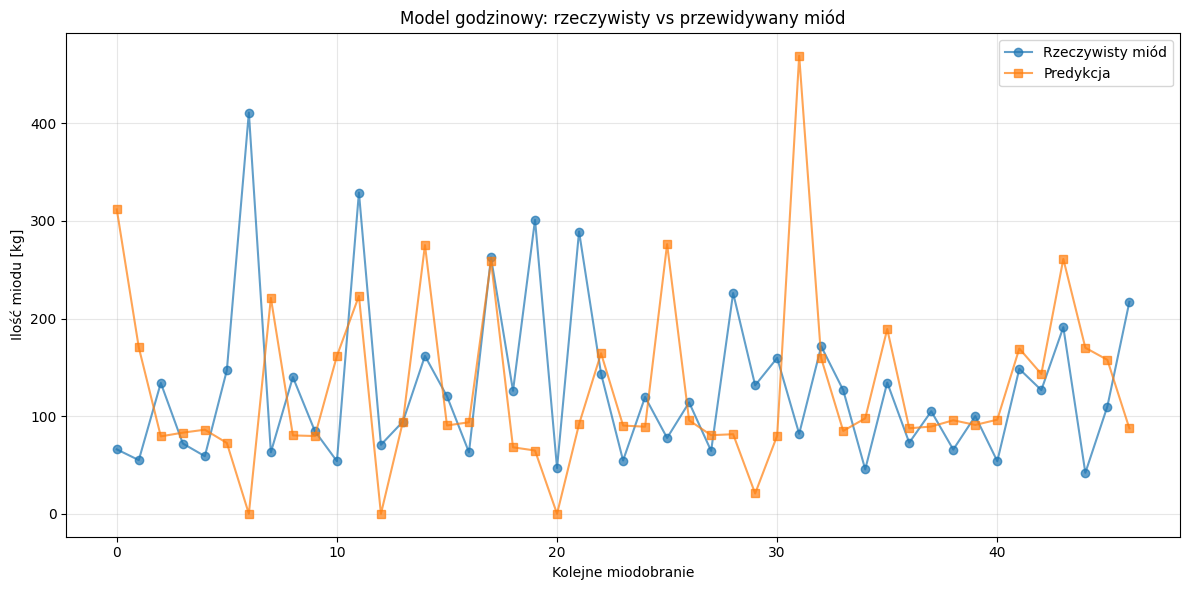

In [42]:
import matplotlib.pyplot as plt

plot_df = honey_sim.sort_values(["year", "week", "harvest"]).reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.plot(
    plot_df["honey"].values,
    label="Rzeczywisty miód",
    marker="o",
    alpha=0.7
)

plt.plot(
    plot_df["predicted_honey"].values,
    label="Predykcja",
    marker="s",
    alpha=0.7
)

plt.legend()
plt.title("Model godzinowy: rzeczywisty vs przewidywany miód")
plt.xlabel("Kolejne miodobranie")
plt.ylabel("Ilość miodu [kg]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()